# Dimensionality Reduction: Finding the Signal in the Noise

## 1. Introduction to Dimensionality Reduction

### 1.1 What is Dimensionality Reduction?
Dimensionality reduction is the process of transforming data from a high-dimensional space into a low-dimensional space while retaining some meaningful properties of the original data. This is crucial in modern data science, where datasets often contain hundreds or thousands of features.

### 1.2 The Curse of Dimensionality
As the number of features (dimensions) increases, the volume of the space increases so fast that the available data becomes sparse. This sparsity is problematic for any method that requires statistical significance. In high-dimensional spaces, all objects appear to be sparse and dissimilar in many ways, which prevents common data organization strategies from being efficient.

### 1.3 Feature Selection vs. Feature Extraction
- **Feature Selection**: Choosing a subset of the original features (e.g., using Mutual Information).
- **Feature Extraction**: Creating new, lower-dimensional features from the original ones (e.g., PCA, t-SNE).

### 1.4 Linear vs. Non-Linear Techniques
- **Linear**: Assumes data lies on or near a linear subspace (e.g., PCA).
- **Non-Linear (Manifold Learning)**: Assumes data lies on a low-dimensional manifold embedded in a high-dimensional space (e.g., t-SNE, UMAP).


## 2. Principal Component Analysis (PCA)

### 2.1 Theoretical Foundations
PCA is a linear dimensionality reduction technique that transforms the data into a new coordinate system such that the greatest variance by any projection of the data comes to lie on the first coordinate (called the first principal component), the second greatest variance on the second coordinate, and so on.

**Goal**: Project high-dimensional data onto a lower-dimensional subspace while preserving as much variance as possible.


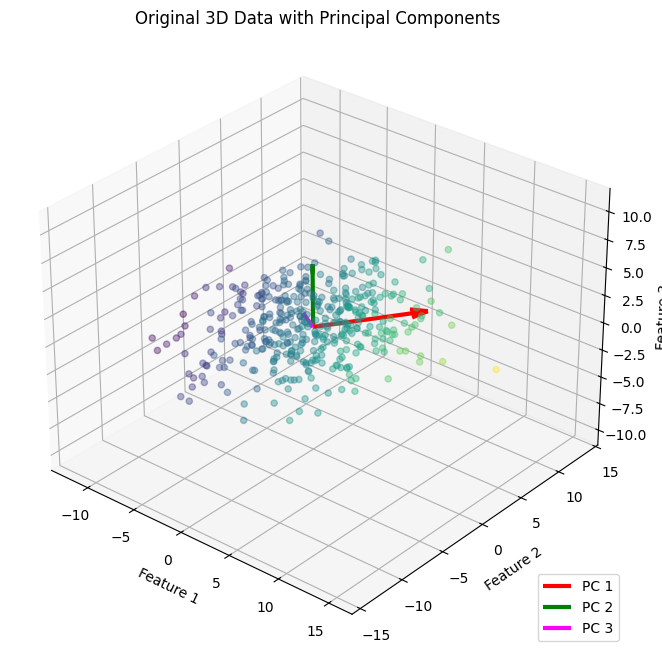

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Required for 3D plotting

# Create a synthetic 3D dataset using multivariate normal for more controlled correlation
np.random.seed(42)
mean_3d = np.array([0, 0, 0])
# Rotated covariance matrix to show correlated data and rotated PCs
cov_3d = np.array([[20, 8, 3],
                   [8, 10, 5],
                   [3, 5, 5]])
X_3d = np.random.multivariate_normal(mean_3d, cov_3d, 400) # Increased size for better visualization

# Apply PCA to get all 3 principal components for plotting
pca_3d = PCA(n_components=3)
pca_3d.fit(X_3d)

# Visualize the original 3D data and principal components
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=X_3d[:, 0], cmap='viridis', alpha=0.4)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
ax.set_title('Original 3D Data with Principal Components')

# # Define distinct colors for each principal component
colors = ['red', 'green', 'magenta']

# Plot principal components as vectors originating from the mean of the data
for i, (length, vector) in enumerate(zip(pca_3d.explained_variance_, pca_3d.components_)):
    v = vector * 2 * np.sqrt(length) # Scale vector slightly less for better visualization
    ax.quiver(0, 0, 0, v[0], v[1], v[2], color=colors[i], arrow_length_ratio=0.15, linewidth=3, label=f'PC {i+1}')
ax.legend(loc='lower right') # Move legend to the bottom right

# Adjust the viewing angle (elevation, azimuth)
ax.view_init(elev=30, azim=-50)

plt.axis('equal')
plt.show()

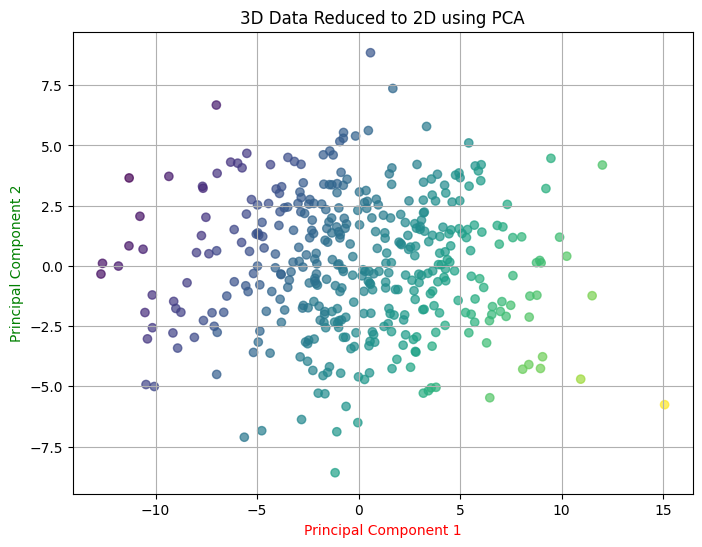

Explained variance ratio (PC1, PC2, PC3): [0.70237588 0.24099204 0.05663208]
Principal components (vectors):
[[ 0.83576904  0.49199045  0.24379399]
 [-0.53274215  0.61907786  0.57699948]
 [ 0.13295077 -0.61211763  0.77951016]]
Total explained variance by 3 components: 1.00


In [ ]:
# Now, apply PCA to reduce to 2 dimensions for the 2D projection plot

pca_3d_to_2d = PCA(n_components=2) # Only 2 components for the projection
X_2d_pca = pca_3d_to_2d.fit_transform(X_3d)

# X_2d_pca = pca_3d.transform(X_3d)[:,:2] #PCA sort the components in order of importance

# Visualize the 2D PCA projection
plt.figure(figsize=(8, 6))
plt.scatter(X_2d_pca[:, 0], X_2d_pca[:, 1], c=X_3d[:, 0], cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1',color='red')
plt.ylabel('Principal Component 2',color='green')
plt.title('3D Data Reduced to 2D using PCA')
plt.grid(True)
plt.show()

print(f"Explained variance ratio (PC1, PC2, PC3): {pca_3d.explained_variance_ratio_}")
print(f"Principal components (vectors):\n{pca_3d.components_}")
print(f"Total explained variance by 3 components: {np.sum(pca_3d.explained_variance_ratio_):.2f}")

In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

# Load the California Housing dataset
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Standardize the data (CRITICAL for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

### 2.2 Explained Variance

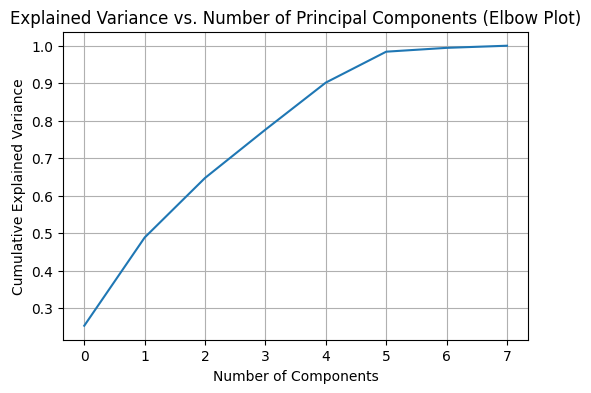

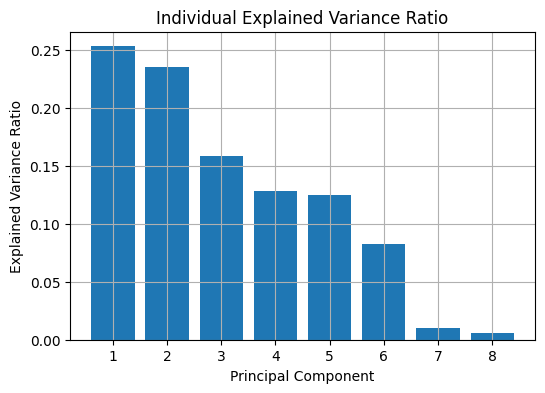

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Apply PCA with all components to get explained variance
pca_full = PCA(n_components=None)
pca_full.fit(X_scaled)

# Plot the explained variance ratio (Elbow Plot)
plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Principal Components (Elbow Plot)')
plt.grid(True)
plt.show()

# Plot individual explained variance ratio
plt.figure(figsize=(6, 4))
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1), pca_full.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Individual Explained Variance Ratio')
plt.grid(True)
plt.show()

From the elbow plot, you can see how much variance each additional principal component explains. The "elbow" point indicates where adding more components provides diminishing returns in terms of explained variance. In this case, the first two components capture a significant portion (almost 50%) of the variance, as seen in the previous PCA plot, which is typical for visualization purposes. The last two components do not contribute much to the variance opf the data, suggesting that they do not contain much information.

### 2.3 Feature Contribution to Principal Components

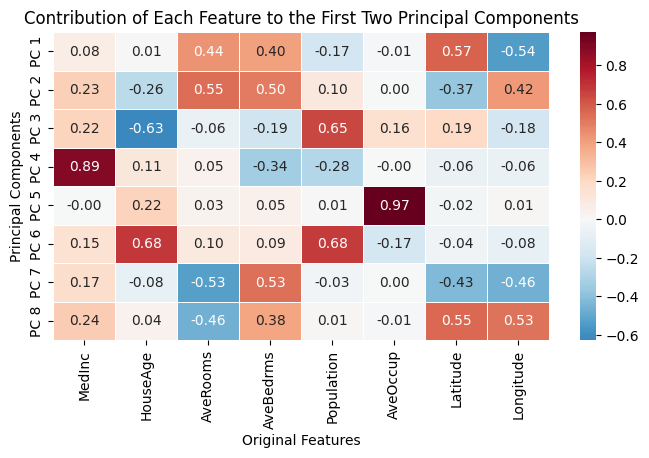

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get the principal components (loadings)
# The 'pca' object used for X_pca has n_components=2
components = pca_full.components_

# Create a DataFrame for better visualization
# Rows are original features, columns are principal components
components_df = pd.DataFrame(components, columns=data.feature_names, index=[f'PC {i+1}' for i in range(pca_full.n_components_)])

plt.figure(figsize=(8, 4))
sns.heatmap(components_df, cmap='RdBu_r', annot=True, fmt=".2f", linewidths=.5, center=0)
plt.title('Contribution of Each Feature to the First Two Principal Components')
plt.xlabel('Original Features')
plt.ylabel('Principal Components')
plt.show()

The heatmap above shows the *loadings* or contributions of each original feature to the first two principal components. A higher absolute value indicates a stronger contribution (either positive or negative) of that feature to the respective principal component. This helps in interpreting what each principal component represents in terms of the original features.

### 2.4 Digits Dataset

(1797, 8, 8)
(1797,)


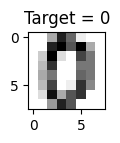

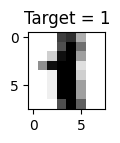

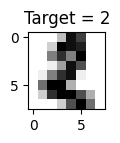

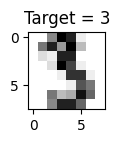

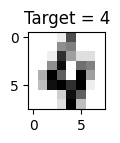

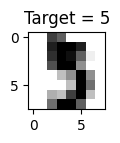

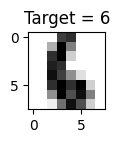

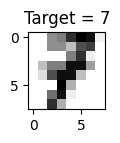

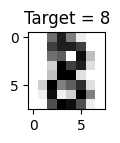

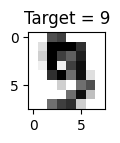

In [ ]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load the Digits dataset
digits = load_digits()


images = digits.images # data
labels = digits.target # labels, we will use them just to observe the behavior of the clustering algorithm


# 1797 8x8 images
print(images.shape)
print(labels.shape)

# # show the first 10 elements and target
for i in range(10):
    plt.figure(figsize=(1,1))
    plt.imshow(images[i], cmap='gray_r')
    plt.title("Target = %d"%(labels[i]))


**Vectorization**: also in this case, we need to convert the image (8x8) into a vector. We naively flatten the image, that is, we concatenate pixels row-wise into a vector of 64 dimensions.

**Note**: flattening the image is usally a bad idea, since it destroys the spatial structure of the data itself, making the analysis by the algorithm more difficult. More advanced techniques, like feature extraction or CNNs are usually applied.

(1797, 64)


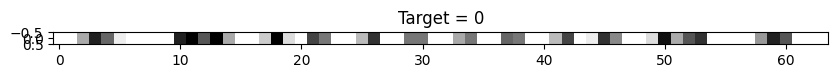

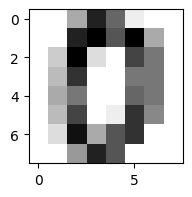

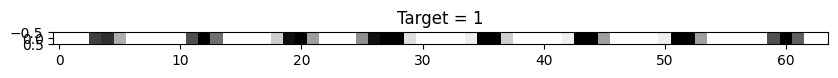

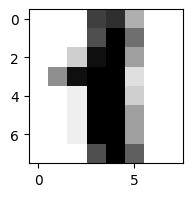

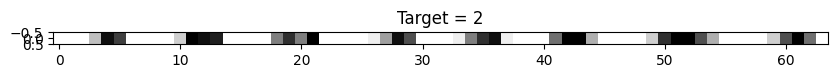

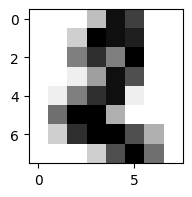

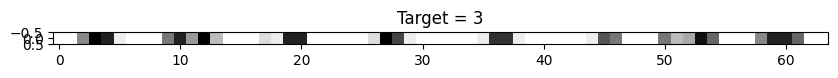

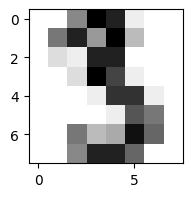

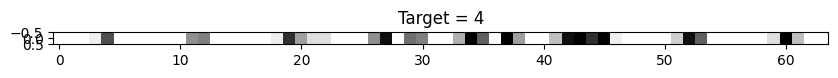

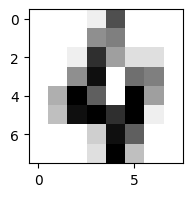

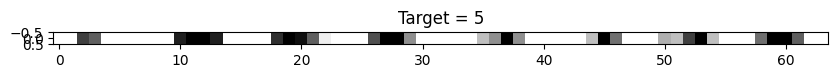

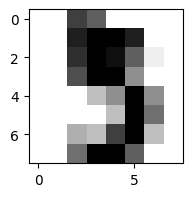

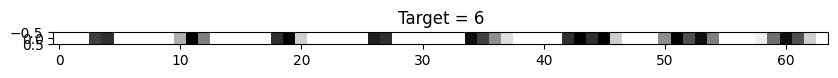

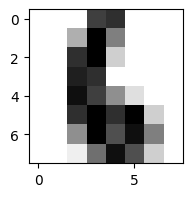

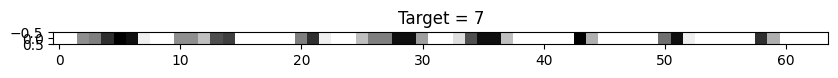

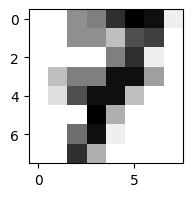

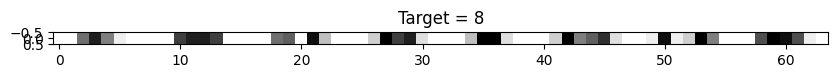

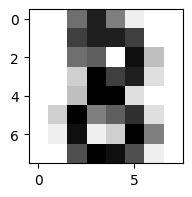

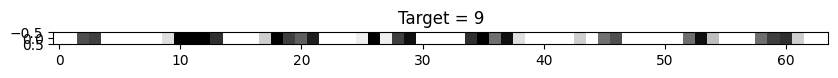

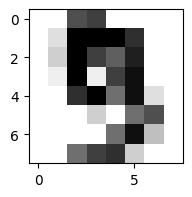

In [ ]:
X_digits = digits.data
y_digits = digits.target

print(X_digits.shape)

for i in range(10):
    plt.figure(figsize=(10,2))
    plt.imshow(X_digits[i,None], cmap='gray_r')
    plt.title("Target = %d"%(labels[i]))
    plt.show()
    plt.figure(figsize=(10,2))
    plt.imshow(images[i], cmap='gray_r')
    plt.show()

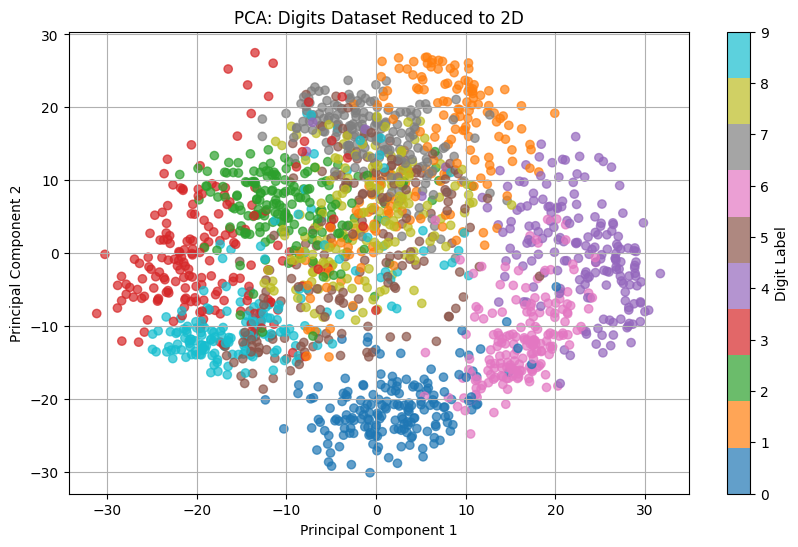

Explained variance ratio (PC1, PC2): [0.14890594 0.13618771]
Total explained variance by 2 components: 0.29


In [ ]:
# Apply PCA to reduce to 2 dimensions
pca_digits = PCA(n_components=2)
X_digits_pca = pca_digits.fit_transform(X_digits)

# Visualize the 2D PCA projection of the Digits dataset
plt.figure(figsize=(10, 6))
plt.scatter(X_digits_pca[:, 0], X_digits_pca[:, 1], c=y_digits, cmap='tab10', alpha=0.7)
plt.colorbar(label='Digit Label')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: Digits Dataset Reduced to 2D')
plt.grid(True)
plt.show()

print(f"Explained variance ratio (PC1, PC2): {pca_digits.explained_variance_ratio_}")
print(f"Total explained variance by 2 components: {sum(pca_digits.explained_variance_ratio_):.2f}")

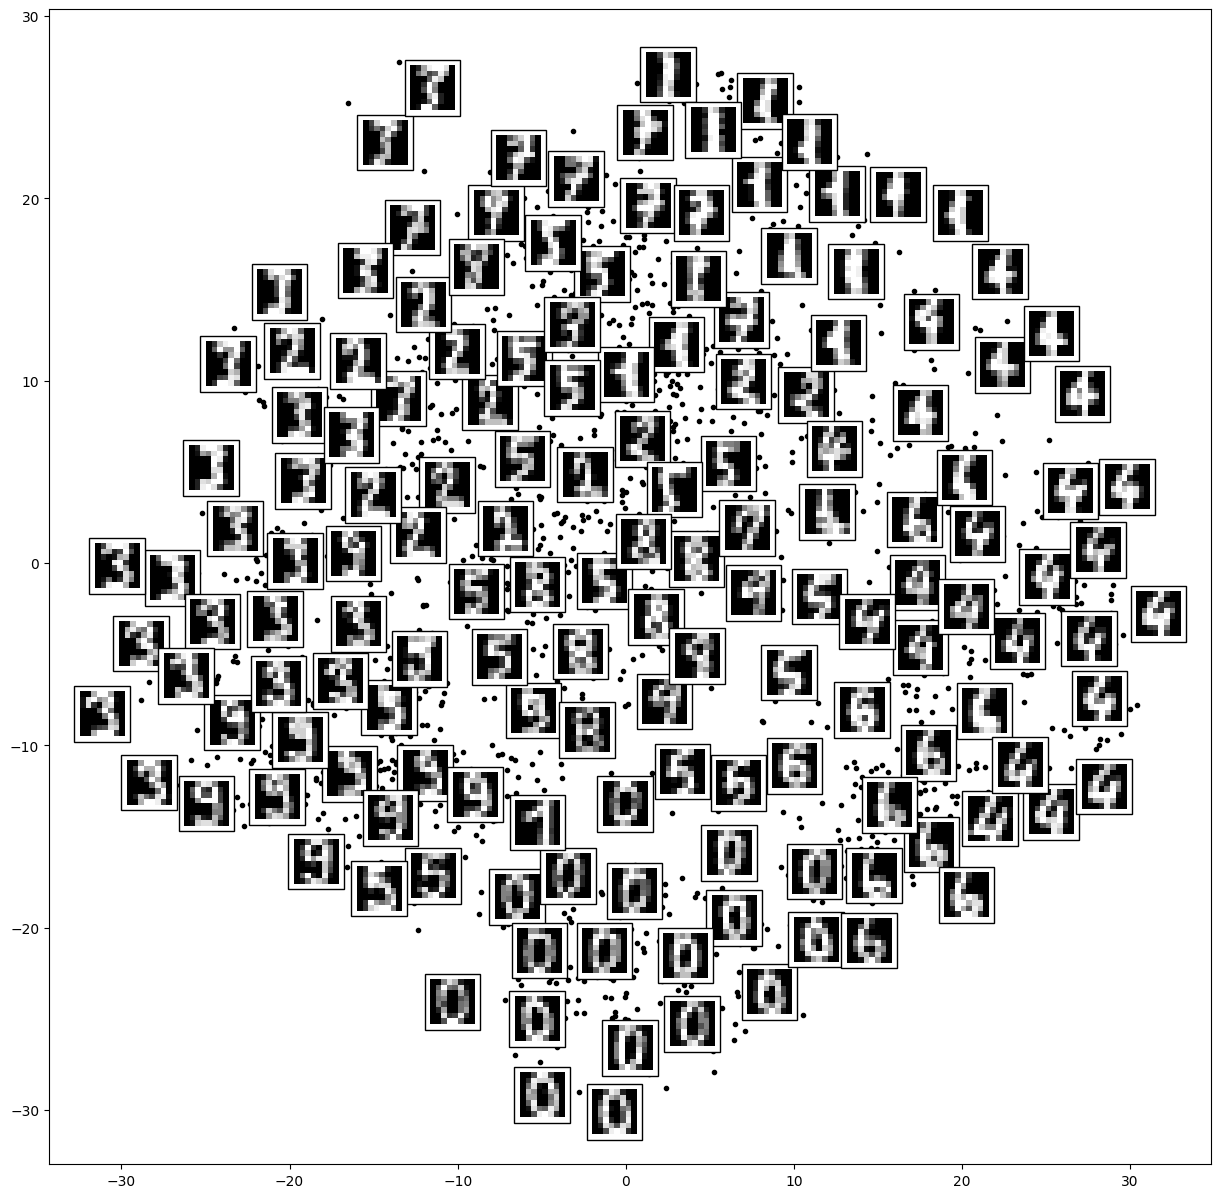

In [ ]:
from matplotlib import offsetbox

def plot_components(proj, images=None, ax=None,
                    thumb_frac=0.05, cmap='gray'):
  ax = ax or plt.gca()

  ax.plot(proj[:, 0], proj[:, 1], '.k')
  if images is not None:
    min_dist_2 = (thumb_frac * max(proj.max(0) - proj.min(0))) ** 2
    shown_images = np.array([2 * proj.max(0)])
    for i in range(proj.shape[0]):
      dist = np.sum((proj[i] - shown_images) ** 2, 1)
      if np.min(dist) < min_dist_2:
        # don't show points that are too close
        continue
      shown_images = np.vstack([shown_images, proj[i]])
      imagebox = offsetbox.AnnotationBbox(offsetbox.OffsetImage(images[i], cmap=cmap, zoom=4), proj[i])
      ax.add_artist(imagebox)

fig, ax = plt.subplots(figsize=(15,15))
plot_components(X_digits_pca,images)

## 3. t-Distributed Stochastic Neighbor Embedding (t-SNE)

### 3.1 Theoretical Foundations
t-SNE is a non-linear dimensionality reduction technique primarily used for visualization. It works by converting high-dimensional Euclidean distances between points into conditional probabilities that represent similarities. It then tries to minimize the divergence between these probabilities in the high-dimensional and low-dimensional spaces.

**Goal**: Preserve local neighborhoods (similar points remain close, dissimilar points remain far apart).


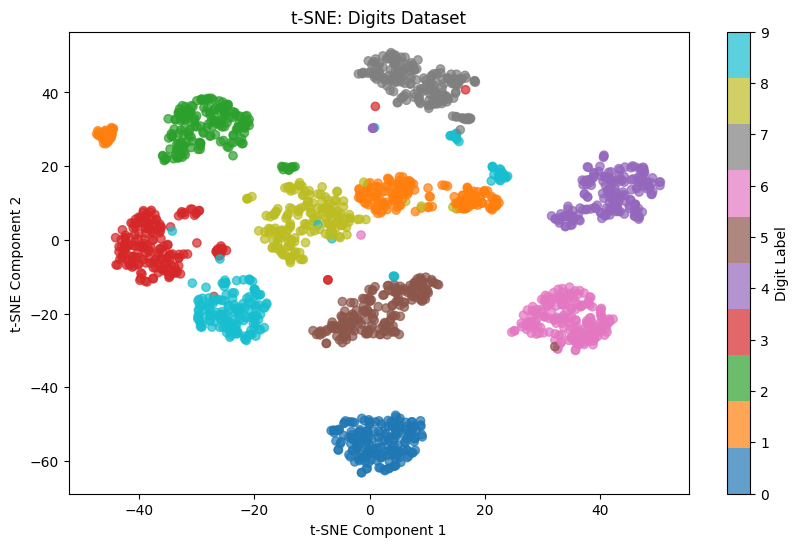

In [ ]:
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits

# Load the Digits dataset
# digits = load_digits()
# X_digits = digits.data
# y_digits = digits.target

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_digits)

# Plot t-SNE results
plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_digits, cmap='tab10', alpha=0.7)
plt.colorbar(label='Digit Label')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE: Digits Dataset')
plt.show()

### 3.2 Influence of Perplexity Parameter in t-SNE

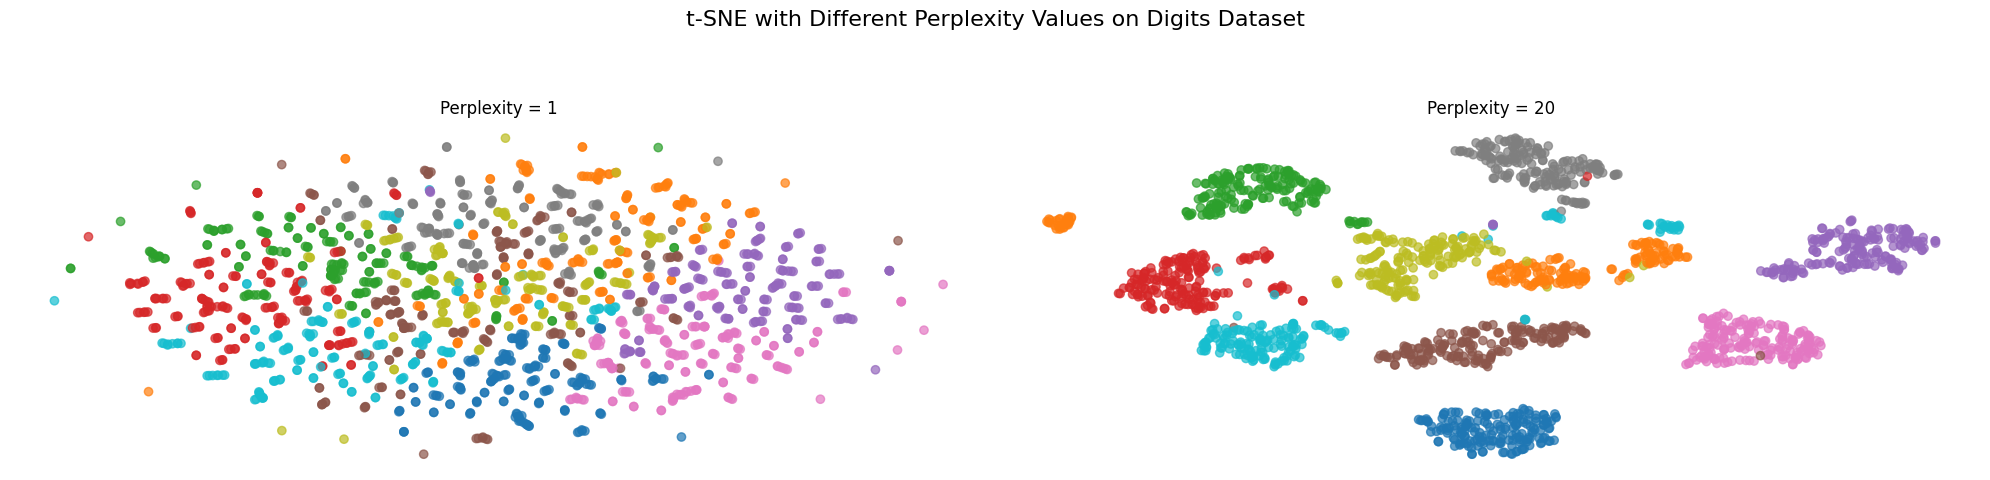

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Load the Digits dataset (if not already loaded)
# from sklearn.datasets import load_digits
# digits = load_digits()
# X_digits = digits.data
# y_digits = digits.target

perplexity_values = [1,20] # Example perplexity values

plt.figure(figsize=(20, 5))
plt.suptitle('t-SNE with Different Perplexity Values on Digits Dataset', fontsize=16)

for i, perplexity in enumerate(perplexity_values):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init='pca', learning_rate='auto')
    X_tsne_perplexity = tsne.fit_transform(X_digits)

    plt.subplot(1, len(perplexity_values), i + 1)
    plt.scatter(X_tsne_perplexity[:, 0], X_tsne_perplexity[:, 1], c=y_digits, cmap='tab10', alpha=0.7)
    plt.title(f'Perplexity = {perplexity}')
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

## 4. Uniform Manifold Approximation and Projection (UMAP)

### 4.1 Theoretical Foundations
UMAP is a modern non-linear dimensionality reduction technique that is faster and often preserves more of the global structure than t-SNE. It is based on manifold learning and topological data analysis.

**Goal**: General-purpose dimensionality reduction, suitable for both visualization and feature extraction.


In [ ]:
import umap

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


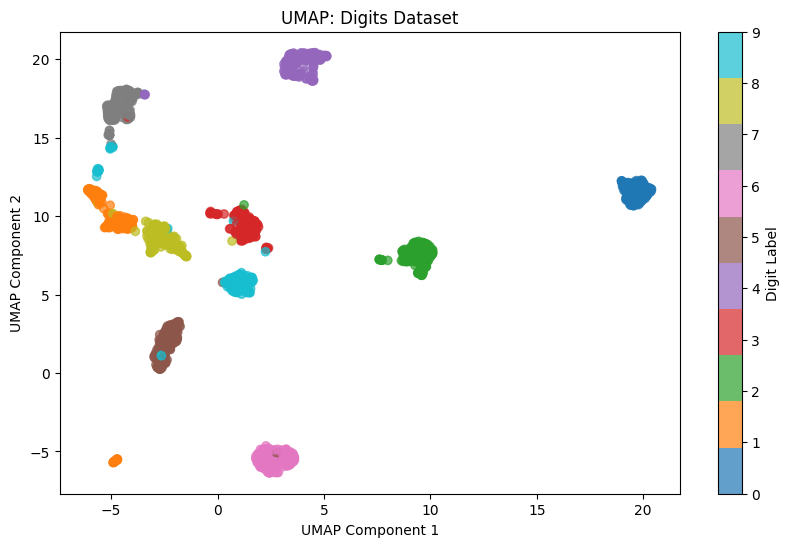

In [ ]:
# Apply UMAP
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_digits)

# Plot UMAP results
plt.figure(figsize=(10, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_digits, cmap='tab10', alpha=0.7)
plt.colorbar(label='Digit Label')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('UMAP: Digits Dataset')
plt.show()

### 4.2 Influence of Parameters in UMAP

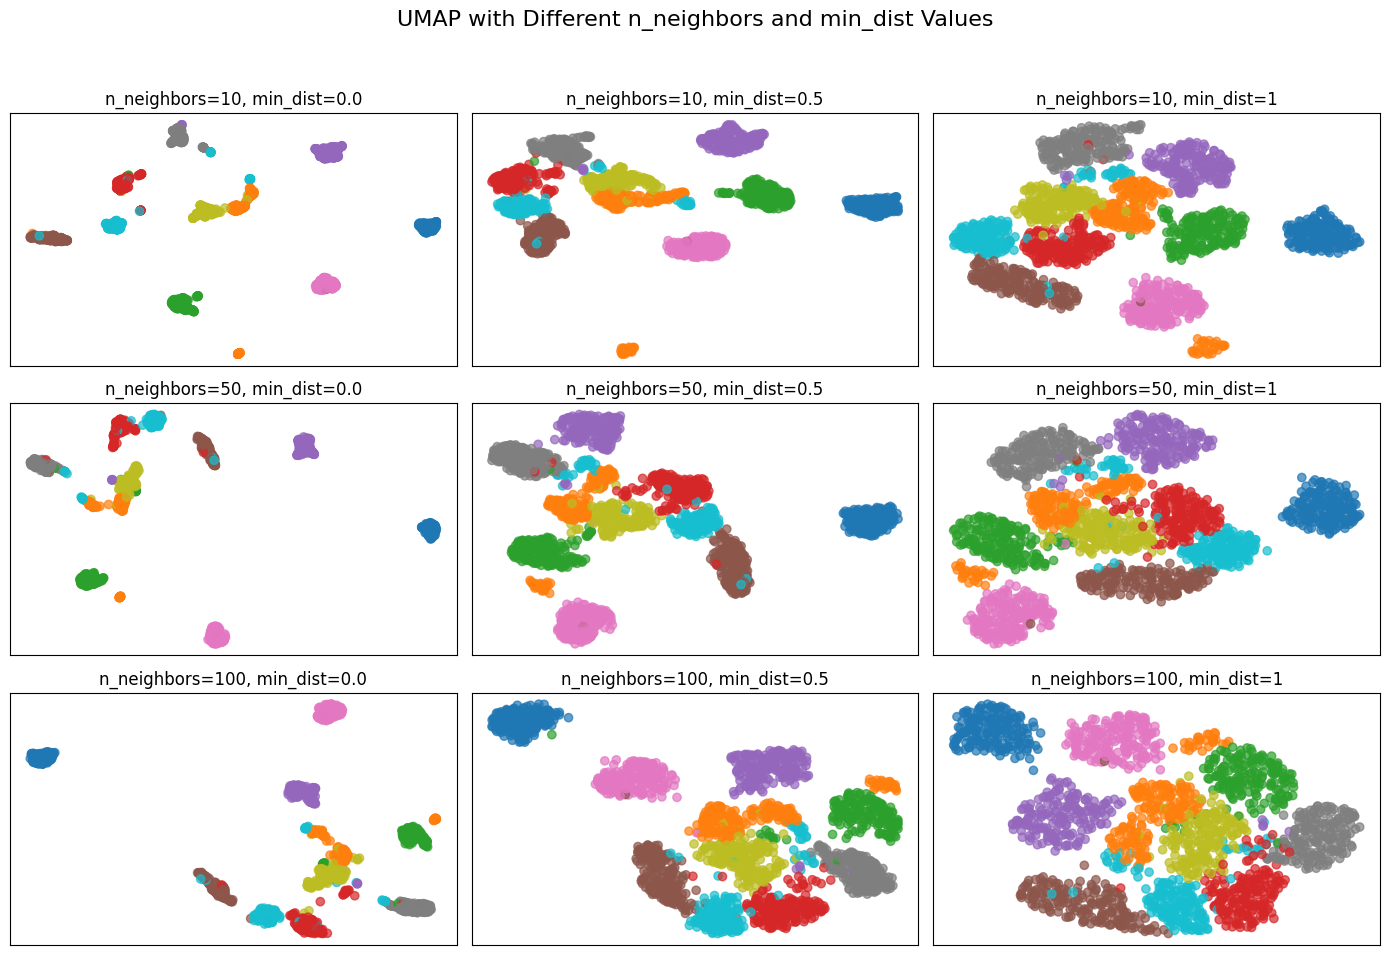

In [ ]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# Load the Digits dataset (if not already loaded)
# from sklearn.datasets import load_digits
# digits = load_digits()
# X_digits = digits.data
# y_digits = digits.target

n_neighbors_values = [10, 50, 100] # Example n_neighbors values
min_dist_values = [0.0, 0.5, 1] # Example min_dist values

fig, axes = plt.subplots(len(n_neighbors_values), len(min_dist_values), figsize=(14, 10))
fig.suptitle('UMAP with Different n_neighbors and min_dist Values', fontsize=16)

for i, n_neighbors in enumerate(n_neighbors_values):
    for j, min_dist in enumerate(min_dist_values):
        reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist)
        X_umap_params = reducer.fit_transform(X_digits[::1])

        ax = axes[i, j]
        scatter = ax.scatter(X_umap_params[:, 0], X_umap_params[:, 1], c=y_digits[::1], cmap='tab10', alpha=0.7)
        ax.set_title(f'n_neighbors={n_neighbors}, min_dist={min_dist}')
        ax.set_xticks([])
        ax.set_yticks([])

# cbar = fig.colorbar(scatter, ax=axes.ravel().tolist(), orientation='vertical', shrink=0.75)
# cbar.set_label('Digit Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 5. Comparative Analysis & Best Practices

### 5.1 PCA vs. t-SNE vs. UMAP
| Technique | Type | Goal | Strengths | Weaknesses |
| :--- | :--- | :--- | :--- | :--- |
| **PCA** | Linear | Maximize Variance | Fast, interpretable, deterministic | Fails on non-linear data |
| **t-SNE** | Non-Linear | Local Structure | Excellent for visualization | Slow, stochastic, poor global structure |
| **UMAP** | Non-Linear | Global & Local | Fast, scalable, preserves global structure | More complex parameters |

### 5.2 When to Use Which Technique?
- **PCA**: Data compression, noise reduction, linear relationships.
- **t-SNE**: High-quality visualization of clusters.
- **UMAP**: Faster visualization, better global structure preservation, suitable for feature extraction.

### 5.3 Business Applications
- **Customer Segmentation**: t-SNE or UMAP to visualize customer groups.
- **Anomaly Detection**: PCA for identifying outliers.
- **Fraud Detection**: UMAP for cluster identification.
- **Drug Discovery**: UMAP for chemical space exploration.

## 6. Resources

Here are references to the relevant machine learning functions and libraries used in this notebook:

*   **Scikit-learn (sklearn)**:
    *   `sklearn.decomposition.PCA`: [PCA Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
    *   `sklearn.manifold.TSNE`: [t-SNE Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)
    *   `sklearn.datasets.load_digits`: [Load Digits Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html)
    *   `sklearn.datasets.fetch_california_housing`: [Fetch California Housing Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california.html)
    *   `sklearn.preprocessing.StandardScaler`: [StandardScaler Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

*   **UMAP (Uniform Manifold Approximation and Projection)**:
    *   `umap.UMAP`: [UMAP Documentation](https://umap-learn.readthedocs.io/en/latest/api.html#umap.UMAP)